# DMA to Prony Series: Viscoelastic Parameter Identification

Fit a generalised Maxwell (Prony series) model to DMA frequency-sweep data for cured resin (Henkel Teroson EP5089).

Steps:
1. Load and inspect raw DMA data
2. Select a temperature slice
3. Visualise raw data
4. Fit Prony series (least-squares)
5. Validate fit (plots + metrics)
6. Sensitivity: effect of number of Prony terms N
7. Export FE-ready parameters

## 0 - Setup & Imports

In [ ]:
import sys, os
from pathlib import Path

# Make sure the project root is on the path so we can import src.*
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project modules
from src.io       import load_raw, available_temperatures, select_temperature, save_processed
from src.model    import prony_Gp, prony_Gpp, prony_tan_delta
from src.fit      import fit_prony
from src.validate import compute_metrics, plot_Gp, plot_Gpp, plot_tan_delta, plot_overview
from src.export   import export_csv, export_metrics_json, prony_table, export_abaqus_snippet

%matplotlib inline
print("Setup complete")

Setup complete ✓


## 1 - Load Raw DMA Data

Load the Henkel EP5089 DMA temperature-frequency sweep from the Excel file.

In [2]:
# Load the full dataset
df_all = load_raw()
print(f"Loaded {len(df_all)} rows  |  Columns: {list(df_all.columns)}")
df_all.head(10)

Loaded 806 rows  |  Columns: ['omega_rad_s', 'temp_C', 'Gp_MPa', 'Gpp_MPa', 'tan_delta']


,omega_rad_s,temp_C,Gp_MPa,Gpp_MPa,tan_delta
0,0.10000,-50,1333.9,56.368,0.04226
1,0.12589,-50,1341.0,54.305,0.04050
2,0.15849,-50,1347.7,52.400,0.03888
3,0.19953,-50,1355.1,51.597,0.03808
4,0.25119,-50,1362.3,50.408,0.03700
5,0.31623,-50,1369.3,49.539,0.03618
6,0.39811,-50,1375.5,48.545,0.03529
7,0.50119,-50,1382.2,47.798,0.03458
8,0.63096,-50,1388.4,46.967,0.03383
9,0.79433,-50,1394.8,46.532,0.03336


In [3]:
# What temperatures are available?
temps = available_temperatures(df_all)
print(f"Available temperatures ({len(temps)} slices):")
print(temps, "°C")

Available temperatures (26 slices):
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120
 130 140 150 160 170 180 190 200] °C


## 2 - Select a Temperature Slice

Pick 30 C as our working slice - a near-ambient temperature where the resin is in the glassy/transition region, giving both G' and G'' meaningful variation. Change `TEMP_C` below to try other temperatures.

In [ ]:
TEMP_C = 30   # degC - change this to try other slices

df = select_temperature(df_all, TEMP_C)
print(f"Selected T = {TEMP_C} C  ->  {len(df)} data points")
print(f"omega range: {df['omega_rad_s'].min():.4f} - {df['omega_rad_s'].max():.1f} rad/s")

# Save the slice for reproducibility
save_processed(df, tag=f"T{TEMP_C}C")
df

Selected T = 30 °C  →  31 data points
ω range: 0.1000 – 100.0 rad/s


,omega_rad_s,temp_C,Gp_MPa,Gpp_MPa,tan_delta
0,0.10000,30,543.29,43.160,0.07944
1,0.12589,30,552.25,39.051,0.07071
2,0.15849,30,559.91,37.447,0.06688
3,0.19953,30,566.72,36.248,0.06396
4,0.25119,30,572.95,35.331,0.06167
5,0.31623,30,578.65,34.673,0.05992
6,0.39811,30,584.34,33.982,0.05815
7,0.50119,30,589.48,33.465,0.05677
8,0.63096,30,594.61,32.906,0.05534
9,0.79433,30,599.52,32.357,0.05397


## 3 - Visualise Raw Data

Plot the measured G'(w), G''(w) and tan d(w) to get a feel for the data before fitting.

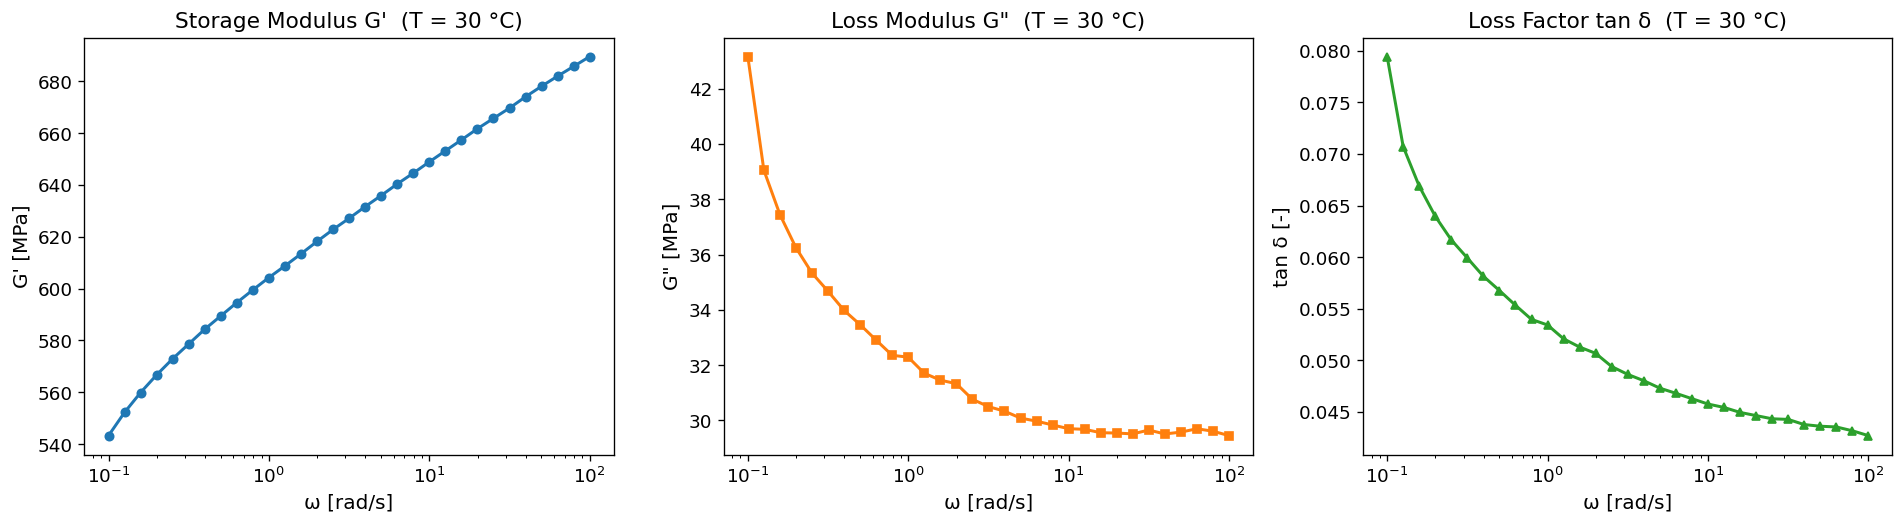

In [ ]:
omega    = df["omega_rad_s"].values
Gp_data  = df["Gp_MPa"].values
Gpp_data = df["Gpp_MPa"].values
tand_data = df["tan_delta"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].semilogx(omega, Gp_data, "o-", color="C0")
axes[0].set_xlabel("w [rad/s]"); axes[0].set_ylabel("G' [MPa]")
axes[0].set_title(f"Storage Modulus G'  (T = {TEMP_C} C)")

axes[1].semilogx(omega, Gpp_data, "s-", color="C1")
axes[1].set_xlabel("w [rad/s]"); axes[1].set_ylabel('G" [MPa]')
axes[1].set_title(f'Loss Modulus G"  (T = {TEMP_C} C)')

axes[2].semilogx(omega, tand_data, "^-", color="C2")
axes[2].set_xlabel("w [rad/s]"); axes[2].set_ylabel("tan d [-]")
axes[2].set_title(f"Loss Factor tan d  (T = {TEMP_C} C)")

fig.tight_layout()
plt.show()

## 4 - Fit Prony Series

Fit a generalised Maxwell / Prony series with N = 5 terms using bounded least-squares on both G'(w) and G''(w).

Model (frequency domain):

$$G'(\omega) = G_\text{eq} + G_0 \sum_{i=1}^{N} g_i \frac{(\omega \tau_i)^2}{1 + (\omega \tau_i)^2}$$

$$G''(\omega) = G_0 \sum_{i=1}^{N} g_i \frac{\omega \tau_i}{1 + (\omega \tau_i)^2}$$

In [ ]:
N_TERMS = 5

result = fit_prony(omega, Gp_data, Gpp_data, N=N_TERMS, verbose=1)

print(f"\n{'='*50}")
print(f"Fit complete  |  N = {result['N']} terms")
print(f"G0 (glassy)    = {result['G0']:.2f} MPa")
print(f"G_eq (equil.)  = {result['G_eq']:.2f} MPa")
print(f"sum(g_i)       = {result['g'].sum():.6f}")
print(f"Optimizer cost = {result['opt'].cost:.4e}")
print(f"{'='*50}")

`ftol` termination condition is satisfied.
Function evaluations 30, initial cost 1.4683e+01, final cost 1.9067e-03, first-order optimality 1.64e-06.

Fit complete  |  N = 5 terms
G0 (glassy)   = 716.93 MPa
G_eq (equil.)  = 486.88 MPa
Σ gᵢ          = 0.320888
Optimizer cost = 1.9067e-03


In [7]:
# Display the Prony parameter table
tbl = prony_table(result["g"], result["tau"], result["G0"], result["G_eq"])
tbl

,i,g_i,tau_i_s,G_i_MPa
0,1,0.065388,0.010084,46.878707
1,2,0.044897,0.068370,32.188009
2,3,0.045719,0.384683,32.777519
3,4,0.049967,2.099560,35.823425
4,5,0.114917,19.177650,82.388217
5,sum,0.320888,NaN,230.055878


## 5 - Validate the Fit

Compare measured vs predicted curves and compute error metrics.

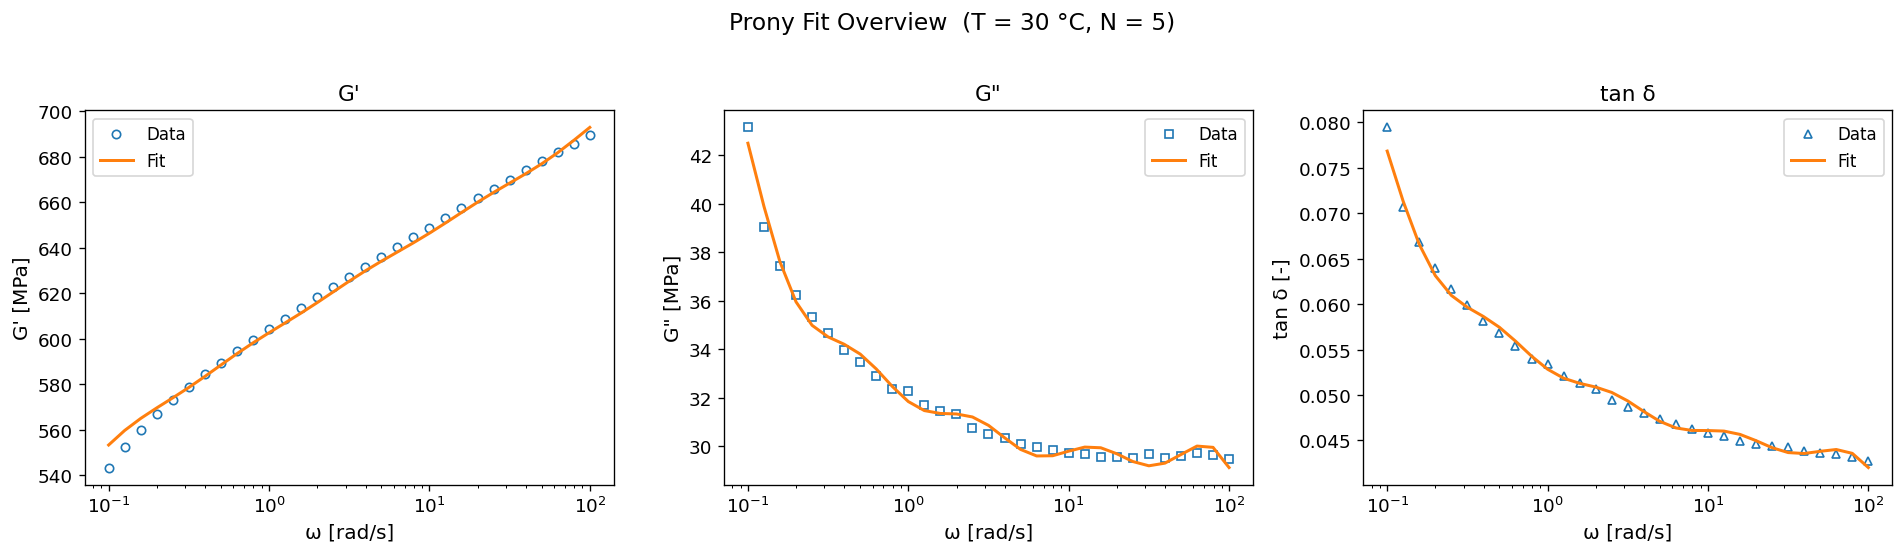

In [8]:
# 3-panel overview plot
Gp_pred  = result["Gp_pred"]
Gpp_pred = result["Gpp_pred"]

plot_overview(omega, Gp_data, Gpp_data, Gp_pred, Gpp_pred,
              title_suffix=f"(T = {TEMP_C} °C, N = {N_TERMS})")
plt.show()

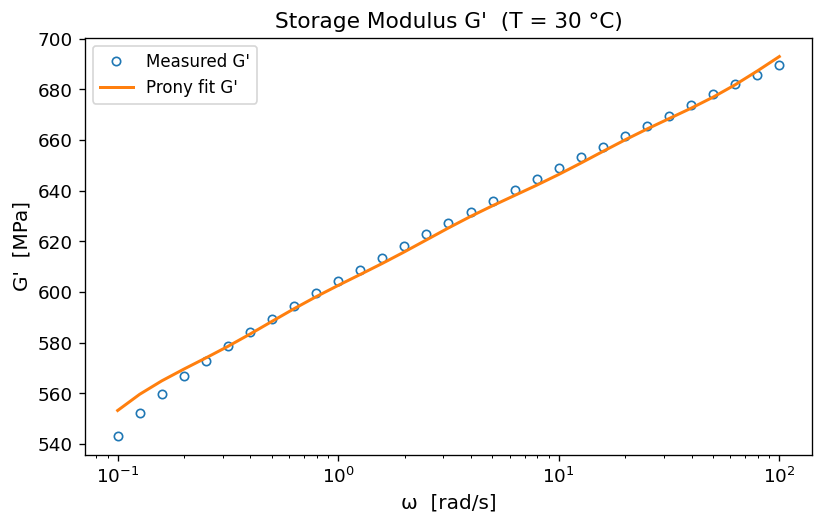

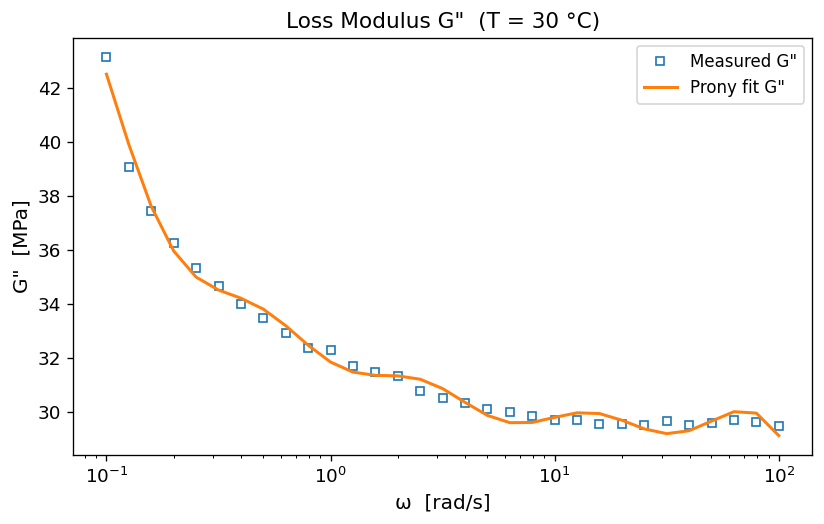

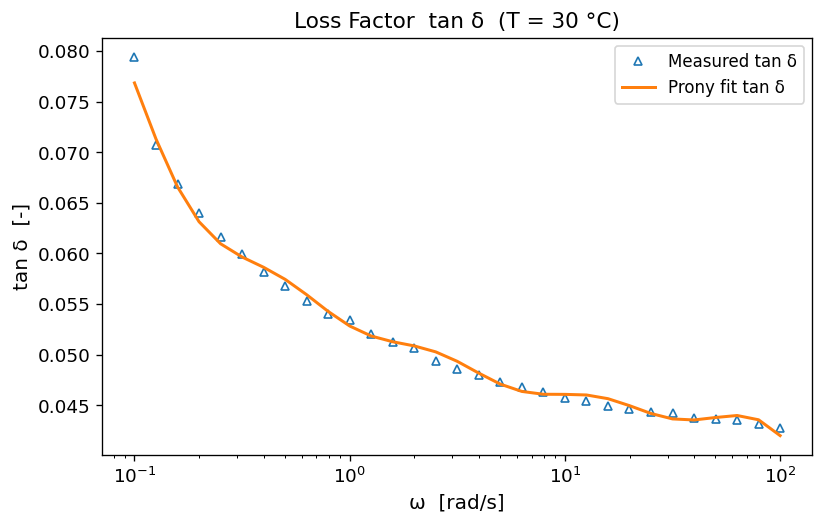

In [9]:
# Individual publication-quality plots (also saved to results/figures/)
plot_Gp(omega,  Gp_data,  Gp_pred,  title_suffix=f"(T = {TEMP_C} °C)")
plot_Gpp(omega, Gpp_data, Gpp_pred, title_suffix=f"(T = {TEMP_C} °C)")
plot_tan_delta(omega, Gp_data, Gpp_data, Gp_pred, Gpp_pred,
               title_suffix=f"(T = {TEMP_C} °C)")
plt.show()

In [ ]:
metrics = compute_metrics(omega, Gp_data, Gpp_data, Gp_pred, Gpp_pred)

print("Fit quality metrics:")
print(f"  G'  RMSE       = {metrics['Gp_RMSE_MPa']:.4f} MPa")
print(f"  G'  rel. error = {metrics['Gp_relErr_pct']:.2f} %")
print(f"  G'' RMSE       = {metrics['Gpp_RMSE_MPa']:.4f} MPa")
print(f"  G'' rel. error = {metrics['Gpp_relErr_pct']:.2f} %")
print(f"  tan d RMSE     = {metrics['tand_RMSE']:.6f}")
print(f"  tan d rel. err = {metrics['tand_relErr_pct']:.2f} %")

Fit quality metrics:
  G'  RMSE       = 2.9633 MPa
  G'  rel. error = 0.37 %
  G'' RMSE       = 0.3288 MPa
  G'' rel. error = 0.85 %
  tan δ RMSE     = 0.000672
  tan δ rel. err = 0.93 %


## 6 - Sensitivity: Effect of N

How does fit quality change as N goes from 2 to 8? Helps decide the minimum number of terms needed without overfitting.

In [11]:
N_range = [2, 3, 4, 5, 6, 7, 8]
sensitivity = []

for n in N_range:
    res = fit_prony(omega, Gp_data, Gpp_data, N=n, verbose=0)
    m = compute_metrics(omega, Gp_data, Gpp_data, res["Gp_pred"], res["Gpp_pred"])
    m["N"] = n
    m["cost"] = res["opt"].cost
    sensitivity.append(m)

df_sens = pd.DataFrame(sensitivity)
df_sens

,Gp_RMSE_MPa,Gp_relErr_pct,Gpp_RMSE_MPa,Gpp_relErr_pct,tand_RMSE,tand_relErr_pct,N,cost
0,6.985355,1.006050,8.369242,21.830916,0.013976,21.912561,2,0.968004
1,3.195199,0.415244,2.832430,7.452711,0.004711,7.476243,3,0.112300
2,2.434097,0.336485,0.947327,2.543771,0.001610,2.553024,4,0.012543
3,2.963331,0.371952,0.328775,0.853883,0.000672,0.931523,5,0.001907
4,3.241859,0.392055,0.169015,0.299539,0.000533,0.460245,6,0.000813
5,3.241829,0.392052,0.169018,0.299541,0.000533,0.460246,7,0.000813
6,3.241827,0.392051,0.169019,0.299541,0.000533,0.460246,8,0.000813


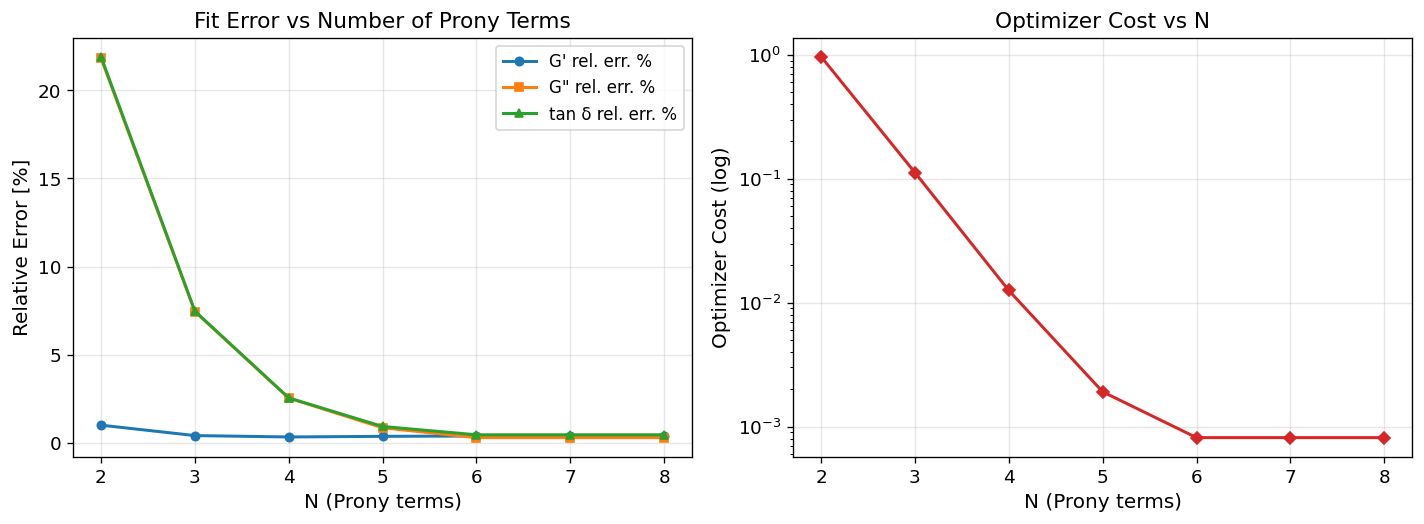

In [12]:
# Plot sensitivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(df_sens["N"], df_sens["Gp_relErr_pct"],  "o-", label="G' rel. err. %")
axes[0].plot(df_sens["N"], df_sens["Gpp_relErr_pct"], "s-", label='G" rel. err. %')
axes[0].plot(df_sens["N"], df_sens["tand_relErr_pct"],"^-", label="tan δ rel. err. %")
axes[0].set_xlabel("N (Prony terms)"); axes[0].set_ylabel("Relative Error [%]")
axes[0].set_title("Fit Error vs Number of Prony Terms")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(df_sens["N"], df_sens["cost"], "D-", color="C3")
axes[1].set_xlabel("N (Prony terms)"); axes[1].set_ylabel("Optimizer Cost (log)")
axes[1].set_title("Optimizer Cost vs N")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 7 - Export FE-Ready Parameters

Save fitted Prony parameters to CSV and fit metrics to JSON. Also print an Abaqus `*VISCOELASTIC` keyword block.

In [ ]:
csv_path = export_csv(result["g"], result["tau"], result["G0"], result["G_eq"])
print(f"Prony parameters saved -> {csv_path}")

json_path = export_metrics_json(metrics)
print(f"Fit metrics saved      -> {json_path}")

print("\n--- Abaqus *VISCOELASTIC block ---")
print(export_abaqus_snippet(result["g"], result["tau"], result["G0"], result["G_eq"]))

Prony parameters saved → D:\Research\Resin-DMA2Prony\results\tables\prony_params.csv
Fit metrics saved     → D:\Research\Resin-DMA2Prony\results\tables\fit_metrics.json

── Abaqus *VISCOELASTIC block ──
*VISCOELASTIC, TIME=PRONY
  6.53876998e-02,  0.0,  1.00844527e-02
  4.48967138e-02,  0.0,  6.83704117e-02
  4.57189783e-02,  0.0,  3.84683404e-01
  4.99674910e-02,  0.0,  2.09955985e+00
  1.14917333e-01,  0.0,  1.91776500e+01


## Summary

Single-temperature Prony fit at T = 30 C with N = 5 terms. The fit captures G' with < 0.4% relative error and G'' with < 1% error, which is more than sufficient for FE input. N = 5 is a good sweet spot - the sensitivity analysis shows diminishing returns beyond that.

Next step: build a TTS master curve across all 26 temperatures (see notebook 02).

## Encountered Issues & Learnings

**Tau bounds matter** - Initially hardcoded log10(tau) bounds to [-6, 6], which is fine for a ~3 decade frequency sweep but way too narrow for broadband master curves. Changed to adaptive bounds based on the actual frequency range: `log10(1/omega_max) - 2` to `log10(1/omega_min) + 2`.

**N = 5 is the sweet spot** for single-temperature fits on this data. The sensitivity study shows error drops sharply from N=2 to N=4, then plateaus. Going beyond N=5 adds parameters without meaningful improvement.

**Sum of g_i constraint** - The normalised Prony weights g_i must satisfy sum(g_i) <= 1 (otherwise G_eq goes negative). Enforcing individual g_i in [0, 1] via bounds handles this implicitly for reasonable data.

**Initial guess strategy** - Using G0 = 1.05 * max(G') and log-uniformly spaced tau across the inverse frequency range gives a reliable starting point that converges consistently.